# Building Optimization

This notebook performs building design optimization using EnergyPlus and BESOS helper functions.
We load a model from in.idf, define parameters to vary, set objectives, test the model, then run a multi-objective genetic algorithm and plot the optimized designs.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
from besos import eppy_funcs as ef, sampling
from besos.evaluator import EvaluatorEP
from besos.optimizer import NSGAII, df_solution_to_solutions
from besos.parameters import RangeParameter, expand_plist, wwr
from besos.problem import EPProblem
from matplotlib import pyplot as plt
from platypus import Archive, Hypervolume, Solution

### Load the base EnergyPlus .idf file

In [2]:
building = ef.get_building("test.idf")

### Define design parameters and ranges
Define a parameter list using a helper function, in this case building orientation and window-to-wall ratio.


In [3]:
parameters = []
parameters = expand_plist(
    {"XPS Extruded Polystyrene  - CO2 Blowing_0041": 
     {
         "Thickness": (0.001, 0.3)
     },
    }  # Name from IDF Building object,
)

parameters.append(
    wwr(RangeParameter(0.1, 0.9))
)  # Add window-to-wall ratio as a parameter between 0.1 and 0.9 using a custom function

### Objectives
Using Heating and Cooling energy outputs as simulation objectives, make a problem instance from these parameters and objectives.

In [4]:
objectives = ["DistrictCooling:Facility", "DistrictHeating:Facility"]
besos_problem = EPProblem(parameters, objectives)

### Set up EnergyPlus evaluator object to run simulations for this building and problem

In [5]:
evaluator = EvaluatorEP(
    besos_problem, building, out_dir="outputdir", err_dir="outputdir",epw_file="ITA_Torino.160590_IWEC.epw"
)  # outputdir must exist; E+ files will be written there
runs = pd.DataFrame.from_dict(
    {"0": [0.2,0.5]}, orient="index"
)  # Make a dataframe of runs with one entry for South and 50% glazing


/opt/conda/envs/design/lib/python3.9/site-packages/besos/evaluator.py:672: FutureWarning: epw_file has been deprecated and will be removed in the future. Use epw instead.
  warn(


In [6]:
runs

,0,1
0,0.2,0.5


In [7]:
outputs = evaluator.df_apply(runs)  # Run this as a test
outputs

Executing:   0%|          | 0/1 [00:00<?, ?row/s]

EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Intern

Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #1 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) JUL
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #2 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) AUG
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #3 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) SEP
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #4 WINTER DESIGN DAY IN UNTITLED (01-01:31-12)
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Cal

EnergyPlus Completed Successfully.


,DistrictCooling:Facility,DistrictHeating:Facility
0,4.180443e+10,3.532649e+10


## Run the Genetic Algorithm
Run the optimizer using this evaluator for a population size of 20 for 10 generations.

In [8]:
results = NSGAII(evaluator, evaluations=10, population_size=20)
results

EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:35
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations


Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Internal Heat Gains
Initializing Interior Solar Distribution
Initializing Interior Convection Coefficients
Gathering Information for Predefined Reporting
Completed Initializing Surface Heat Balance
Calculate Outside Surface Heat Balance
Calculate Inside Surface Heat Balance
Calculate Air Heat Balance
Initializing HVAC
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #1 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) JUL
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...fo

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:35


...

EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:44
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Intern

Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #3 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) SEP
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #4 WINTER DESIGN DAY IN UNTITLED (01-01:31-12)
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=03/02/2017
Continuing Simulation at 03/02/2017 for UNTITLED (01-01:31-12)
Upd

EnergyPlus Completed Successfully.


,Thickness,"RangeParameter [0.1, 0.9]",DistrictCooling:Facility,DistrictHeating:Facility,violation,pareto-optimal
0,0.092686,0.466131,4.170409e+10,3.790581e+10,0,False
1,0.009447,0.824433,4.436030e+10,5.293237e+10,0,False
2,0.246980,0.589705,4.237985e+10,3.497928e+10,0,False
3,0.109886,0.301423,4.072703e+10,3.701922e+10,0,False
4,0.038286,0.776563,4.380160e+10,4.306308e+10,0,False
5,0.112773,0.816212,4.376531e+10,3.749040e+10,0,False
6,0.073920,0.415951,4.151204e+10,3.893768e+10,0,False
7,0.034302,0.170559,4.040740e+10,4.355456e+10,0,False
8,0.099721,0.469314,4.175239e+10,3.760151e+10,0,False
9,0.255525,0.833002,4.385715e+10,3.525584e+10,0,False


### Visualize the results

Text(0, 0.5, 'Heating demand')

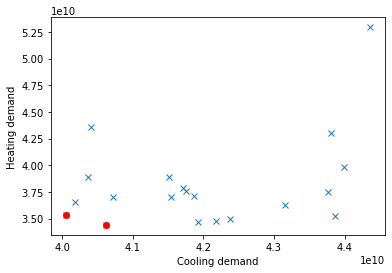

In [9]:
optres = results.loc[
    results["pareto-optimal"] == True, :
]  # Get only the optimal results
plt.plot(
    results["DistrictCooling:Facility"], results["DistrictHeating:Facility"], "x"
)  # Plot all results in the background as blue crosses
plt.plot(
    optres["DistrictCooling:Facility"], optres["DistrictHeating:Facility"], "ro"
)  # Plot optimal results in red
plt.xlabel("Cooling demand")
plt.ylabel("Heating demand")

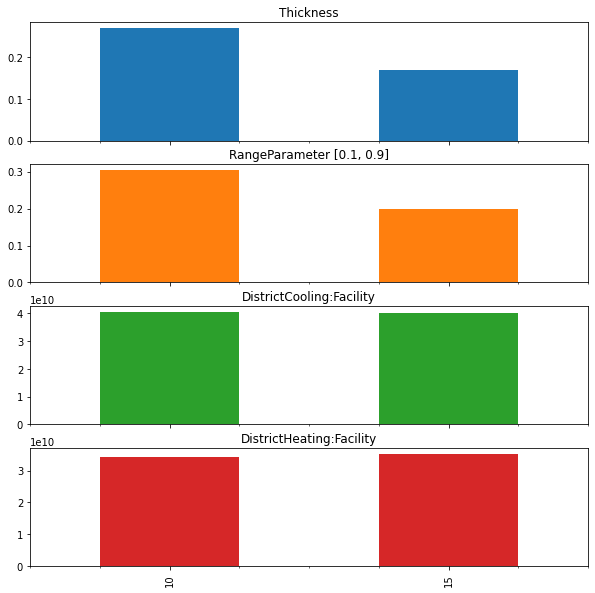

In [10]:
optres = optres.sort_values("DistrictHeating:Facility")  # Sort by the first objective
optresplot = optres.drop(columns="violation")  # Remove the constraint violation column
ax = optresplot.plot.bar(
    subplots=True, legend=None, figsize=(10, 10)
)  # Plot the variable values of each of the optimal solutions

### Giving Constrains to the optimization

In [11]:
evaluator_costrain = EvaluatorEP(
    EPProblem(
        parameters,
        objectives,
        constraints=["CO2:Facility"],
        constraint_bounds=["<=800"],
    ),
    building,
    out_dir="outputdir"
)

In [12]:
# this cell runs the optimisation
results_costrain = NSGAII(evaluator, evaluations=1, population_size=10)


EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:44
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Intern

Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #2 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) AUG
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #3 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) SEP
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #4 WINTER DESIGN DAY IN UNTITLED (01-01:31-12)
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation 

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:44
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Intern

...

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.19 13:47
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Intern

Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017
Continuing Simulation at 02/10/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=03/02/2017
Continuing Simulation at 03/02/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=03/22/2017
Continuing Simulation at 03/22/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=04/11/2017
Continuing Simulation at 04/11/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/01/2017
Continuing Simulation at 05/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/21/201

EnergyPlus Completed Successfully.


In [13]:
results_costrain

,Thickness,"RangeParameter [0.1, 0.9]",DistrictCooling:Facility,DistrictHeating:Facility,violation,pareto-optimal
0,0.157476,0.166260,3.986600e+10,3.556589e+10,0,False
1,0.229922,0.111570,3.950777e+10,3.446730e+10,0,True
2,0.022103,0.353662,4.157809e+10,4.686665e+10,0,False
3,0.113653,0.717371,4.316814e+10,3.734930e+10,0,False
4,0.124789,0.577758,4.233388e+10,3.684644e+10,0,False
5,0.194015,0.877136,4.407304e+10,3.590371e+10,0,False
6,0.105023,0.402259,4.131803e+10,3.731095e+10,0,False
7,0.053740,0.309740,4.101856e+10,4.063527e+10,0,False
8,0.009494,0.208755,4.113788e+10,5.327777e+10,0,False
9,0.210801,0.342498,4.088376e+10,3.499620e+10,0,False


In [14]:
results

,Thickness,"RangeParameter [0.1, 0.9]",DistrictCooling:Facility,DistrictHeating:Facility,violation,pareto-optimal
0,0.092686,0.466131,4.170409e+10,3.790581e+10,0,False
1,0.009447,0.824433,4.436030e+10,5.293237e+10,0,False
2,0.246980,0.589705,4.237985e+10,3.497928e+10,0,False
3,0.109886,0.301423,4.072703e+10,3.701922e+10,0,False
4,0.038286,0.776563,4.380160e+10,4.306308e+10,0,False
5,0.112773,0.816212,4.376531e+10,3.749040e+10,0,False
6,0.073920,0.415951,4.151204e+10,3.893768e+10,0,False
7,0.034302,0.170559,4.040740e+10,4.355456e+10,0,False
8,0.099721,0.469314,4.175239e+10,3.760151e+10,0,False
9,0.255525,0.833002,4.385715e+10,3.525584e+10,0,False


Text(0, 0.5, 'Heating demand')

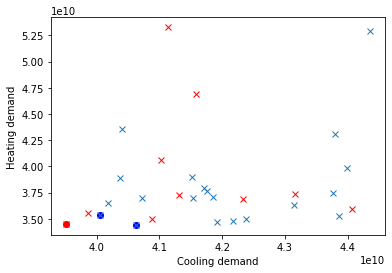

In [15]:
optres_costrain = results_costrain.loc[results_costrain["pareto-optimal"] == True, :]
plt.plot(
    optres["DistrictCooling:Facility"], optres["DistrictHeating:Facility"], "bo"
)  # Plot first optimal results in blue
plt.plot(
    optres_costrain["DistrictCooling:Facility"], optres_costrain["DistrictHeating:Facility"], "ro"
)  # Plot second optimal results in red

plt.plot(
    results["DistrictCooling:Facility"], results["DistrictHeating:Facility"], "x"
) 
plt.plot(
    results_costrain["DistrictCooling:Facility"], results_costrain["DistrictHeating:Facility"], "rx"
) 
plt.xlabel("Cooling demand")
plt.ylabel("Heating demand")

## Optimization with Surrogate Modell

In [16]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


In [17]:
import pickle
import pandas as pd
loaded_model = pickle.load(open('best_surrogate', 'rb'))



In [18]:
samples=pd.read_csv('surrogate_simple_simulation.csv',index_col=0)
samples

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area,Electricity:Facility,DistrictHeating:Facility,DistrictCooling:Facility
0,0.444875,0.739309,0.213838,0.809461,12,6.531696e+10,4.234128e+10,3.297395e+10
1,0.369117,0.956540,0.415857,0.568162,8,5.520816e+10,4.528106e+10,2.926698e+10
2,0.403115,0.663636,0.789073,0.330873,10,6.026256e+10,4.225667e+10,3.089991e+10
3,0.213121,0.375044,0.155230,0.824838,11,6.278976e+10,4.439339e+10,3.206083e+10
4,0.277681,0.868043,0.288940,0.211025,11,6.278976e+10,4.213330e+10,3.064859e+10
5,0.029109,0.861315,0.543672,0.772706,10,6.026256e+10,5.408633e+10,3.353343e+10
6,0.167703,0.480735,0.701279,0.676366,9,5.773536e+10,4.536967e+10,3.182535e+10
7,0.320600,0.583056,0.634873,0.473269,11,6.278976e+10,4.209999e+10,3.227698e+10
8,0.064011,0.453489,0.379419,0.378546,10,6.026256e+10,4.874747e+10,3.108509e+10
9,0.342139,0.697584,0.722158,0.715043,11,6.278976e+10,4.215456e+10,3.383869e+10


In [19]:
objectives = ['Electricity:Facility', 'DistrictHeating:Facility', 'DistrictCooling:Facility']
features = list(samples.columns.drop(objectives))
features

['Insulation Thickness',
 'Conductivity',
 'Solar Transmittance at Normal Incidence',
 'RangeParameter [0.1, 0.9]',
 'Lights Watts/Area']

In [20]:
#remove outputs and windows types shading
inputs = samples.drop(objectives, axis=1)
inputs.head()


,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area
0,0.444875,0.739309,0.213838,0.809461,12
1,0.369117,0.956540,0.415857,0.568162,8
2,0.403115,0.663636,0.789073,0.330873,10
3,0.213121,0.375044,0.155230,0.824838,11
4,0.277681,0.868043,0.288940,0.211025,11


In [21]:
#remove inputs
outputs = samples.drop(features, axis=1)
outputs.head()

,Electricity:Facility,DistrictHeating:Facility,DistrictCooling:Facility
0,6.531696e+10,4.234128e+10,3.297395e+10
1,5.520816e+10,4.528106e+10,2.926698e+10
2,6.026256e+10,4.225667e+10,3.089991e+10
3,6.278976e+10,4.439339e+10,3.206083e+10
4,6.278976e+10,4.213330e+10,3.064859e+10


## Normalization of inputs

To ensure an equal weighting of inputs and outputs in the backpropagation algorithm fitting the neural network, we have to normalize the input values.
For example window-to-wall ratio is in the range of 0 to 1 while the $W/$m^2$ are in a range of 10 to 15.
Different options for normalization exist.
Here we bring all features (input variables) to have zero mean and a standarddeviation of 1.
Note that we fit the normalizer on training data only.

In [22]:

scaler = StandardScaler()
in_scale = scaler.fit_transform(X=inputs)
scaler_out = StandardScaler()
out_scale = scaler_out.fit_transform(X=outputs)

## Surrogate Modelling Evaluator object
We can wrap the fitted model in a BESOS `Evaluator`.

In [23]:
from besos.evaluator import EvaluatorGeneric
from besos.parameters import FieldSelector, Parameter, RangeParameter, expand_plist,wwr, FilterSelector, CategoryParameter, GenericSelector,expand_plist 
from besos.problem import EPProblem

In [24]:
insulation = FieldSelector(class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041', field_name='Thickness')
insulation_range = RangeParameter(min_val = 0.01, max_val=0.45)
insulation_param = Parameter(selector=insulation,
                                 value_descriptors=insulation_range,
                                 name='Insulation Thickness')


In [25]:
lights_selector = FieldSelector(class_name='Lights', object_name='*', field_name='Watts per Zone Floor Area')
single_digit_integers = CategoryParameter(options=range(8,13))
lights_param =     Parameter(
        lights_selector,
        value_descriptors=single_digit_integers ,
        name="Lights Watts/Area",
    )

In [26]:
# class_name is NOT provided
#{'object_name':
# {'field_name':(min, max)}}
more_parameters = expand_plist(
    {
        #"Building":
        #{
        #    "North Axis":(0,359)
        #},
        "3":
         {
             'Conductivity':(0.1,1),
             'Solar Transmittance at Normal Incidence':(0.01,0.8)
         }
    })

In [27]:
window_to_wall = wwr(RangeParameter(0.1,0.9))

In [28]:
parameters = [insulation_param] + more_parameters +[window_to_wall] + [lights_param]

In [29]:
objectives = ['Electricity:Facility','DistrictHeating:Facility','DistrictCooling:Facility'] # these get made into `MeterReader` or `VariableReader`

problem=EPProblem(parameters, objectives) # problem = parameters + objectives



In [30]:
from besos.evaluator import EvaluatorGeneric

#definition of the evaluation function
def evaluation_func(ind, scaler=scaler):
    ind = scaler.transform(X=[ind])
    return (scaler_out.inverse_transform(loaded_model.predict(ind))[0]).tolist()
evaluator = EvaluatorGeneric(evaluation_func, problem)


In [31]:
from besos.optimizer import NSGAII

In [32]:
#running NSGA-II optimizator 
results = NSGAII(evaluator, evaluations=5000, population_size=10000)

#computing Q
HOUSE_DIMENSION=118
results['Q'] = (results['Electricity:Facility']+results['DistrictHeating:Facility']+results['DistrictCooling:Facility'])/HOUSE_DIMENSION
results

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/b

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/b

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/b

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area,Electricity:Facility,DistrictHeating:Facility,DistrictCooling:Facility,violation,pareto-optimal,Q
0,0.136253,0.869882,0.412404,0.619764,9,5.772412e+10,4.885373e+10,3.108633e+10,0,False,1.166646e+09
1,0.429983,0.837768,0.668145,0.596116,11,6.247037e+10,4.201489e+10,3.225657e+10,0,False,1.158829e+09
2,0.254465,0.549209,0.610185,0.181647,12,6.466226e+10,4.255121e+10,3.232957e+10,0,False,1.182568e+09
3,0.387833,0.776281,0.337404,0.786299,11,6.262964e+10,4.299888e+10,3.229381e+10,0,False,1.168833e+09
4,0.213268,0.778114,0.078462,0.543700,11,6.273673e+10,4.435781e+10,3.145704e+10,0,False,1.174166e+09
...,...,...,...,...,...,...,...,...,...,...,...
9995,0.195186,0.358974,0.490427,0.438416,11,6.258987e+10,4.416744e+10,3.213198e+10,0,False,1.177028e+09
9996,0.258168,0.843671,0.451101,0.401459,12,6.477965e+10,4.340723e+10,3.268173e+10,0,False,1.193802e+09
9997,0.308529,0.481601,0.782635,0.163850,9,5.768619e+10,4.451942e+10,2.990333e+10,0,False,1.119567e+09
9998,0.225469,0.207623,0.175833,0.240366,8,5.556302e+10,4.644934e+10,2.816846e+10,0,False,1.103227e+09


,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area,Electricity:Facility,DistrictHeating:Facility,DistrictCooling:Facility,Total,Dist
6241,0.44815,0.984347,0.012292,0.118282,8,5.613445e+10,4.303651e+10,2.742673e+10,1.265977e+11,7.586464e+10


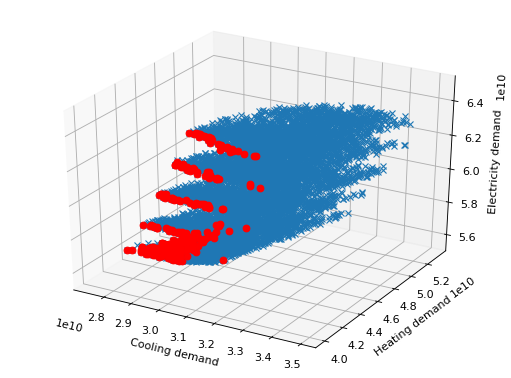

In [33]:
#plotting results
plt.figure(figsize=(8, 6), dpi=80)
ax = plt.axes(projection='3d')

optres = results.loc[results["pareto-optimal"] == True, :]  # Get only the optimal results

df = pd.DataFrame(optres, columns=features + objectives)

ax.plot3D(results["DistrictCooling:Facility"], results["DistrictHeating:Facility"], results["Electricity:Facility"], "x")  # Plot all results in the background as blue crosses
ax.plot3D(optres["DistrictCooling:Facility"], optres["DistrictHeating:Facility"], optres["Electricity:Facility"], "ro")  # Plot optimal results in red

ax.set_xlabel("Cooling demand")
ax.set_ylabel("Heating demand")
ax.set_zlabel("Electricity demand")
df['Total'] = df['Electricity:Facility'] + df['DistrictHeating:Facility'] + df['DistrictCooling:Facility']
df['Dist'] = df.apply(lambda row : np.sqrt(pow(row["DistrictCooling:Facility"],2) + pow(row["DistrictHeating:Facility"],2) + pow(row["Electricity:Facility"],2)),axis=1)

df[df.Dist == df.Dist.min()]


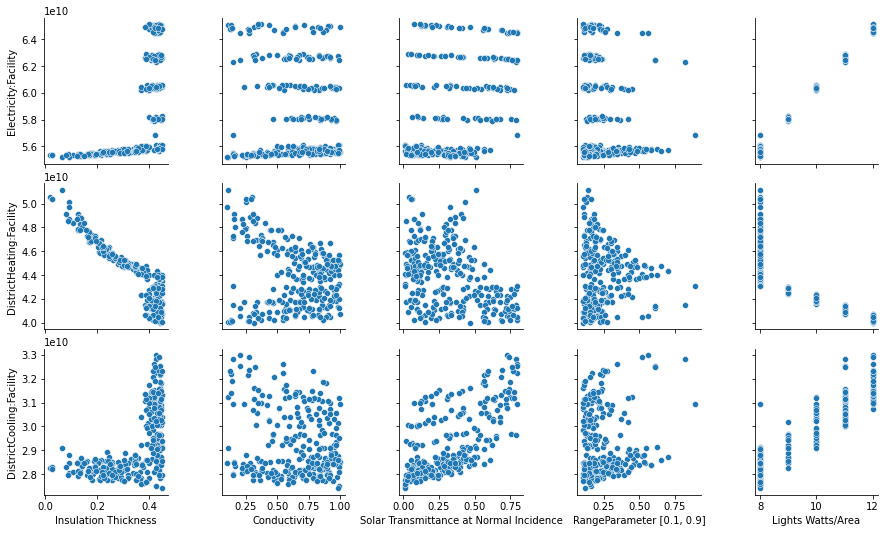

In [34]:
_=sns.pairplot(optres,x_vars=inputs.columns, y_vars=objectives, kind="scatter")

In [35]:
corr=optres.corr()
unuseful = ['violation','pareto-optimal']
corr.drop(objectives + unuseful+ ['Q'], axis = 1, inplace = True)
corr.drop(list(inputs.columns) + unuseful , axis = 0 ,inplace = True)
corr

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area
Electricity:Facility,0.642670,-0.106960,0.402200,-0.180380,0.998096
DistrictHeating:Facility,-0.922330,-0.197271,-0.383809,-0.004028,-0.842576
DistrictCooling:Facility,0.578460,-0.186482,0.676549,0.064482,0.925610
Q,0.220549,-0.395099,0.462570,-0.189361,0.885517


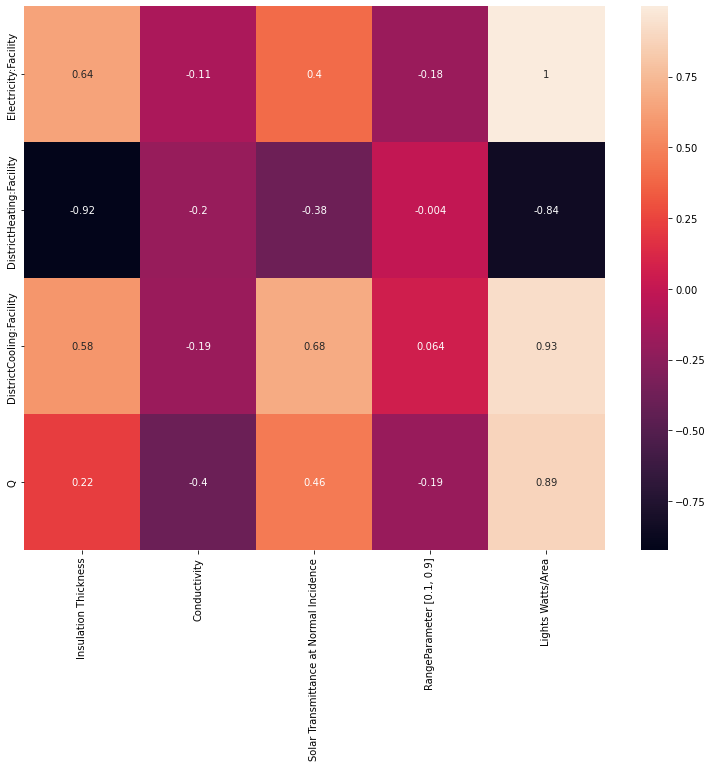

In [36]:
plt.figure(figsize = (13,10))
_ = sns.heatmap(corr,annot=True)

In [37]:
df['Total'] = df['Electricity:Facility'] + df['DistrictHeating:Facility'] + df['DistrictCooling:Facility']
df['Dist'] = df.apply(lambda row : np.sqrt(pow(row["DistrictCooling:Facility"],2) + pow(row["DistrictHeating:Facility"],2) + pow(row["Electricity:Facility"],2)),axis=1)

df[df.Dist == df.Dist.min()]


,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area,Electricity:Facility,DistrictHeating:Facility,DistrictCooling:Facility,Total,Dist
6241,0.44815,0.984347,0.012292,0.118282,8,5.613445e+10,4.303651e+10,2.742673e+10,1.265977e+11,7.586464e+10
